In [17]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field
from langchain_core.messages import SystemMessage, HumanMessage,BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
import os

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

In [2]:
# create class 
class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage],add_messages]

In [5]:
def chat_node(state:ChatState):

    # take user query from message
    messages = state['messages']

    # send to llm 
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

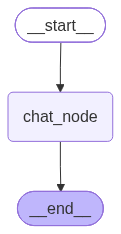

In [18]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [13]:
initial_state = {
    'messages':[HumanMessage(content='What is the capital of rajasthan')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'The capital of Rajasthan is Jaipur.'

In [19]:
thread_id = '1'

while True:

    user_message = input('type here')

    print(user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable':{'thread_id':thread_id}}
    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)

    print('AI : ',response['messages'][-1].content)

hi
AI :  It's nice to meet you. Is there something I can help you with or would you like to chat?
my name is sachin 
AI :  Nice to meet you, Sachin! How's your day going so far? Is there something on your mind that you'd like to talk about, or is it just a casual hello?
what is my name 
AI :  Your name is Sachin! You told me that just a moment ago.
add 30 and 10 
AI :  30 + 10 = 40
add 20 in this 
AI :  We already had 40, and now we're adding 20 to that.

40 + 20 = 60
exit


In [20]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='6dc28192-7243-493c-9c79-40a733259c09'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.04228077, 'completion_tokens_details': None, 'prompt_time': 0.003191062, 'prompt_tokens_details': None, 'queue_time': 0.161079666, 'total_time': 0.045471832}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fa92a-bbc5-7182-995c-ba51029e3378-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59}), HumanMessage(content='my name is sachin ', additional_kwargs={}, response_metadata={}, i

In [16]:
while True:

    user_message = input('type here')

    print(user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]})

    print('AI : ',response['messages'][-1].content)

tell me about crew ai 
AI :  Crew AI is a conversational AI platform designed to enhance customer experience and improve operational efficiency for businesses. Here's an overview of Crew AI:

**Key Features:**

1. **Conversational Interface**: Crew AI provides a conversational interface that allows customers to interact with businesses through messaging platforms, such as SMS, WhatsApp, Facebook Messenger, and more.
2. **AI-Powered Chatbots**: The platform uses artificial intelligence (AI) and machine learning (ML) to power chatbots that can understand and respond to customer inquiries, provide support, and even help with transactions.
3. **Omnichannel Support**: Crew AI supports multiple messaging channels, allowing businesses to engage with customers across various platforms and devices.
4. **Automation and Routing**: The platform includes automation and routing capabilities, enabling businesses to automatically route customer inquiries to the right agents or departments.
5. **Analyt